In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
#load Dataset
df=pd.read_csv("/content/sonar.csv")
print("Dataset Loaded Succesfully")

Dataset Loaded Succesfully


In [ ]:
df.shape

(207, 61)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0.0200  207 non-null    float64
 1   0.0371  207 non-null    float64
 2   0.0428  207 non-null    float64
 3   0.0207  207 non-null    float64
 4   0.0954  207 non-null    float64
 5   0.0986  207 non-null    float64
 6   0.1539  207 non-null    float64
 7   0.1601  207 non-null    float64
 8   0.3109  207 non-null    float64
 9   0.2111  207 non-null    float64
 10  0.1609  207 non-null    float64
 11  0.1582  207 non-null    float64
 12  0.2238  207 non-null    float64
 13  0.0645  207 non-null    float64
 14  0.0660  207 non-null    float64
 15  0.2273  207 non-null    float64
 16  0.3100  207 non-null    float64
 17  0.2999  207 non-null    float64
 18  0.5078  207 non-null    float64
 19  0.4797  207 non-null    float64
 20  0.5783  207 non-null    float64
 21  0.5071  207 non-null    float64
 22  0.

In [ ]:
df.describe()

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,...,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000
mean,0.029208,0.038443,0.043837,0.054053,0.075105,0.104599,0.121591,0.134677,0.177361,0.208245,...,0.016034,0.013472,0.010729,0.010917,0.009300,0.008181,0.007771,0.007947,0.007936,0.006523
std,0.023038,0.033040,0.038521,0.046583,0.055669,0.059247,0.061897,0.085340,0.118311,0.134741,...,0.012027,0.009628,0.007071,0.007310,0.007103,0.005719,0.005756,0.006485,0.006196,0.005038
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013300,0.016400,0.018900,0.024450,0.037700,0.066950,0.080600,0.080350,0.096750,0.111150,...,0.008350,0.007350,0.005050,0.005350,0.004100,0.004400,0.003700,0.003600,0.003650,0.003100
50%,0.022800,0.030800,0.034200,0.044100,0.062000,0.092100,0.105600,0.111900,0.152200,0.181000,...,0.013800,0.011500,0.009600,0.009300,0.007500,0.006800,0.005900,0.005800,0.006300,0.005300
75%,0.035800,0.048100,0.058200,0.065700,0.101050,0.134150,0.153050,0.169800,0.231500,0.269000,...,0.020700,0.016750,0.014900,0.014450,0.012100,0.010350,0.010350,0.010400,0.010350,0.008550
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [ ]:
duplicate=df.duplicated().sum()
print("No.of Duplicates: ",duplicate)

No.of Duplicates:  0


In [ ]:
df.isnull().sum()

,0
0.0200,0
0.0371,0
0.0428,0
0.0207,0
0.0954,0
...,...
0.0180,0
0.0084,0
0.0090,0
0.0032,0


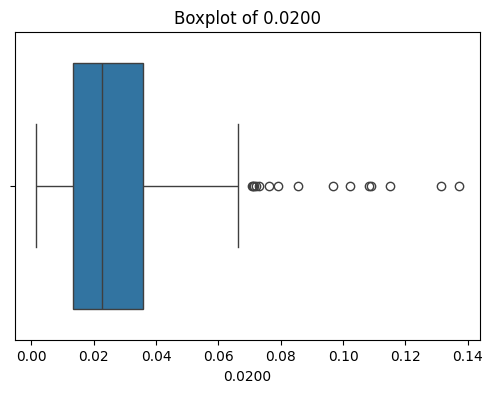

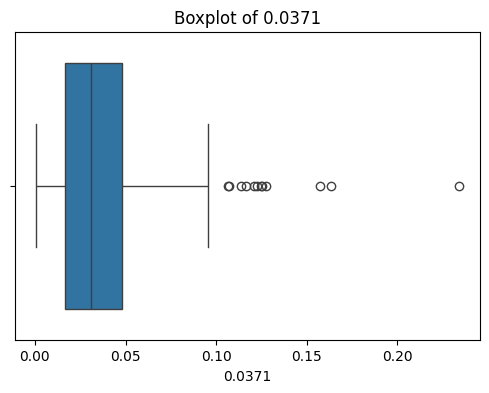

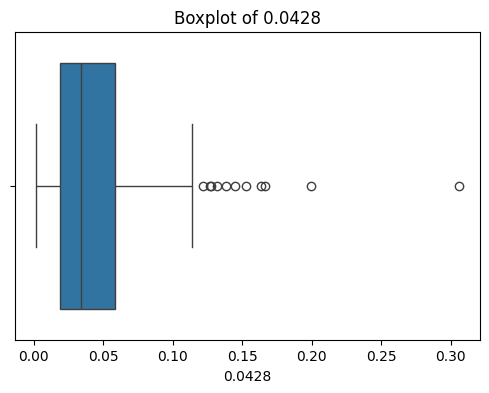

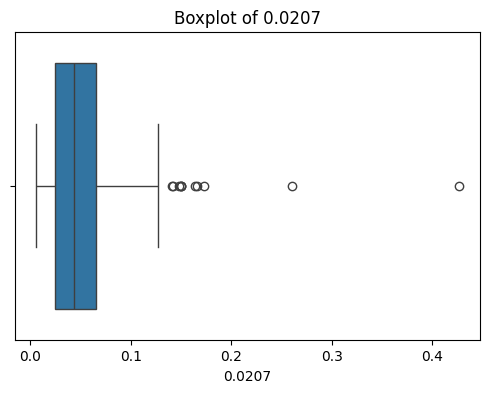

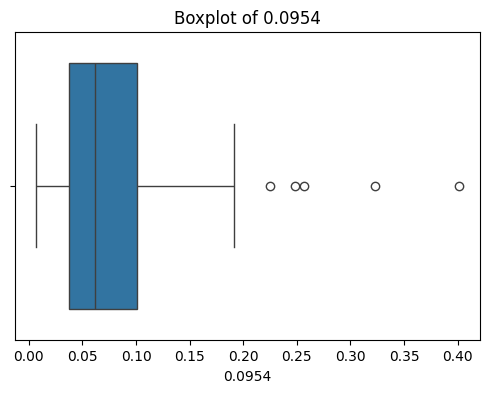

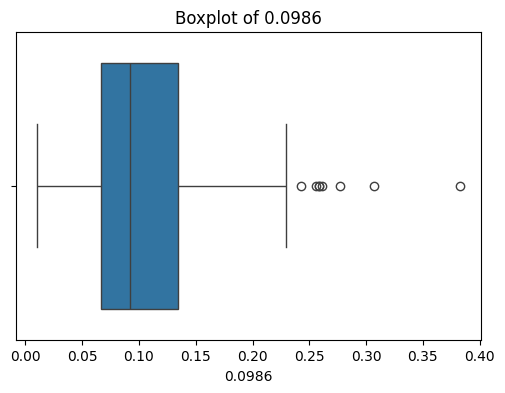

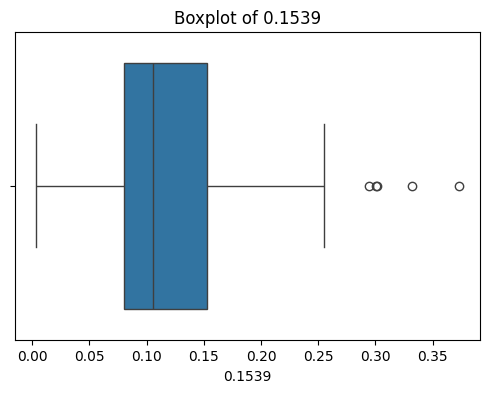

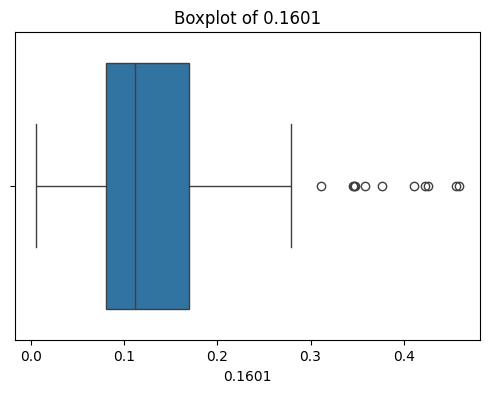

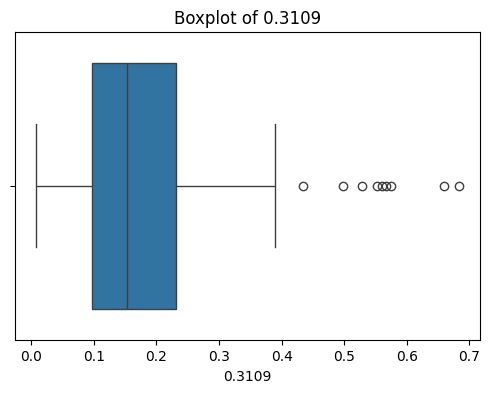

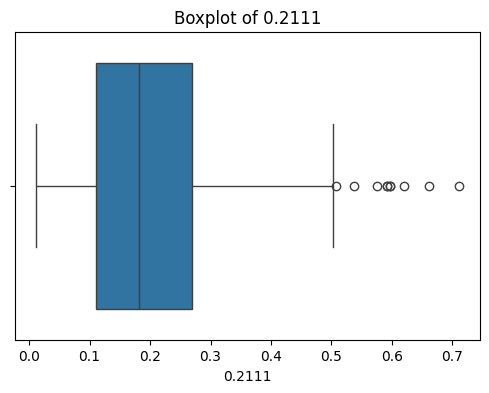

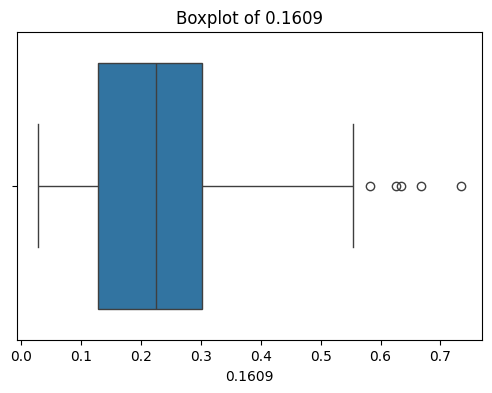

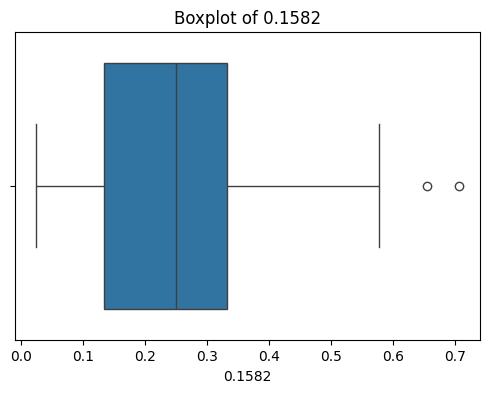

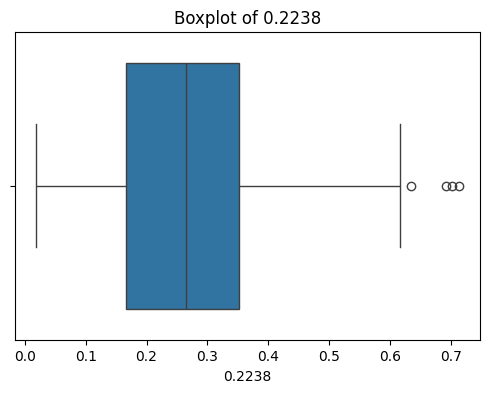

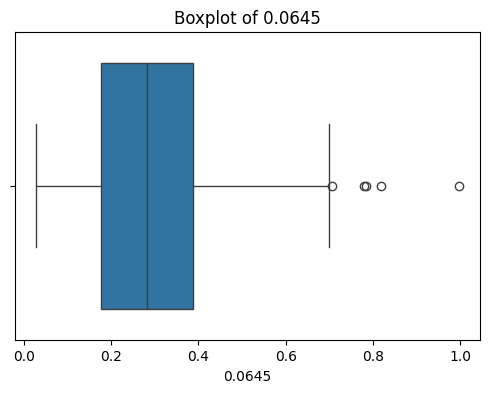

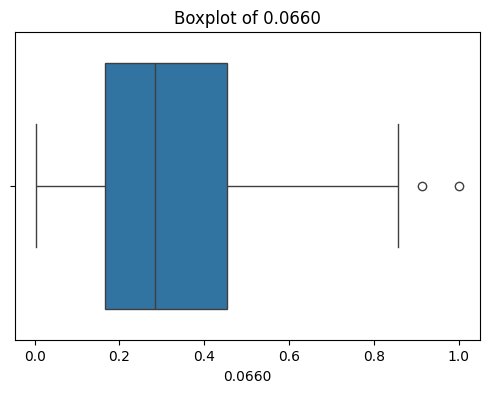

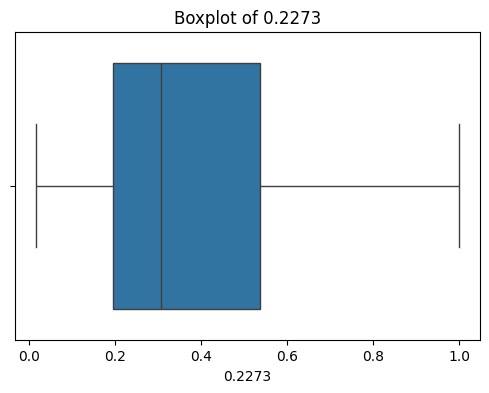

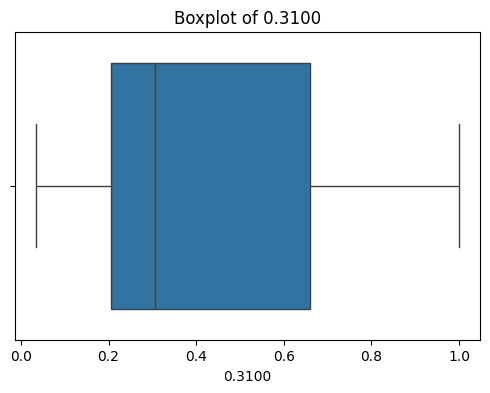

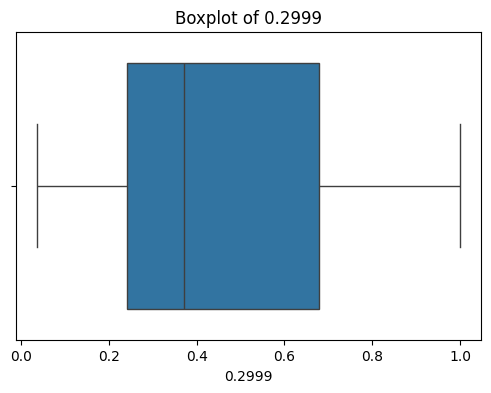

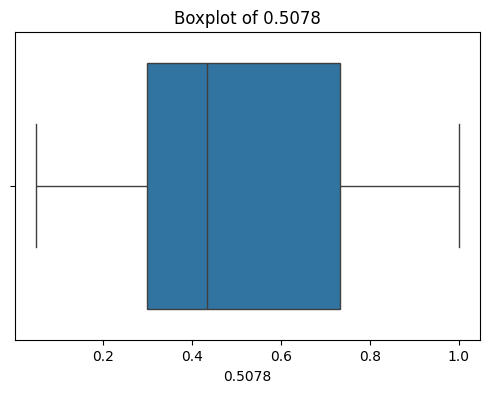

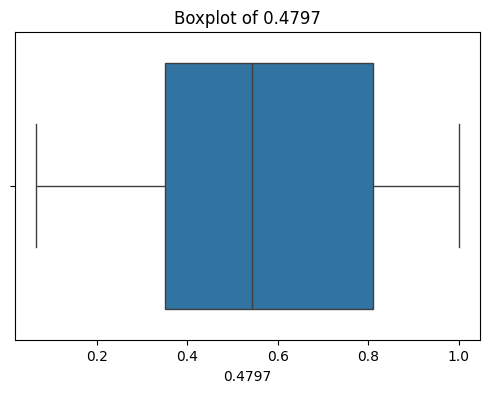

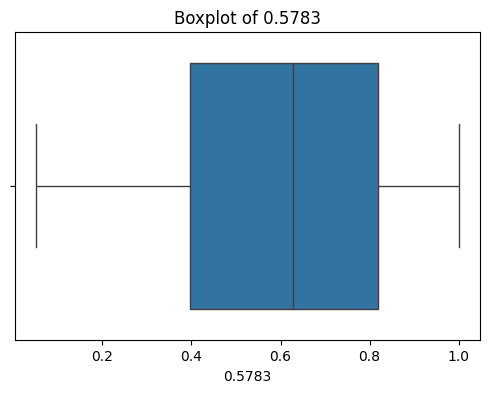

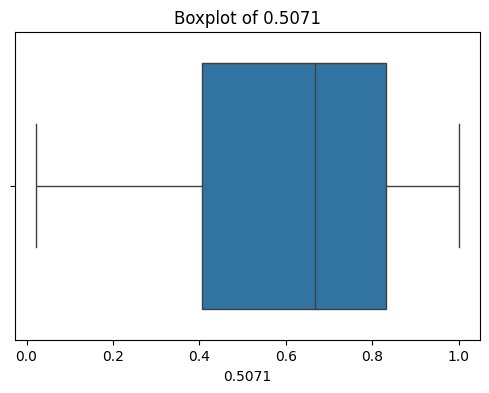

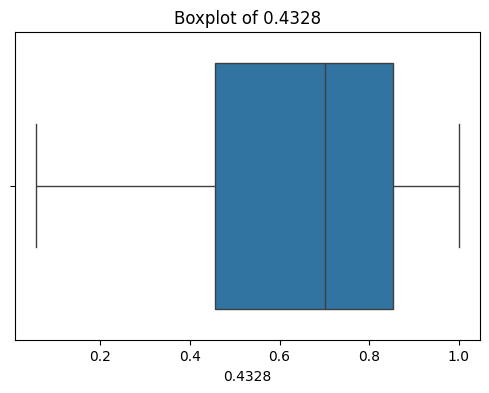

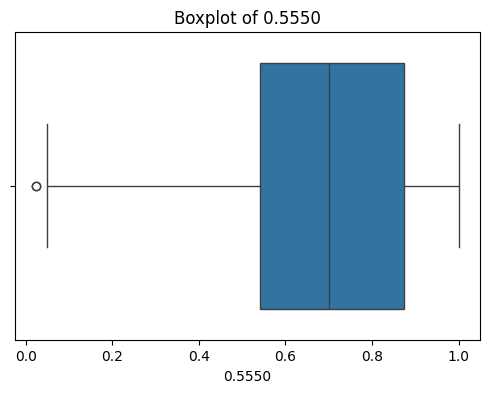

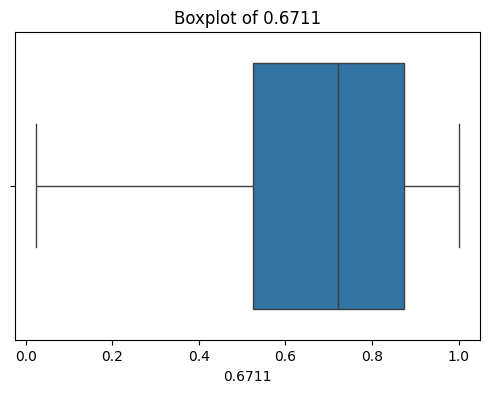

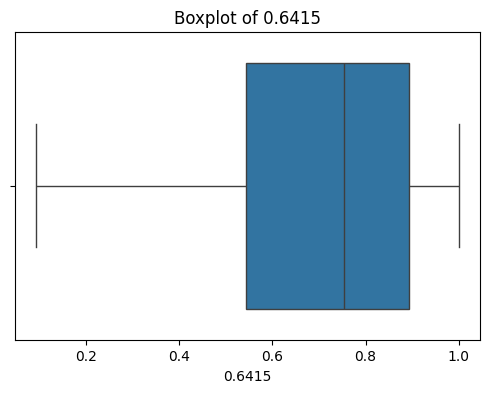

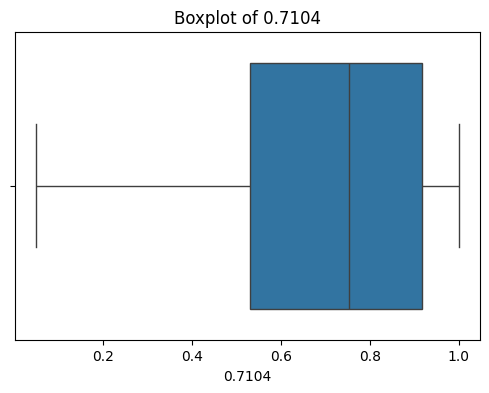

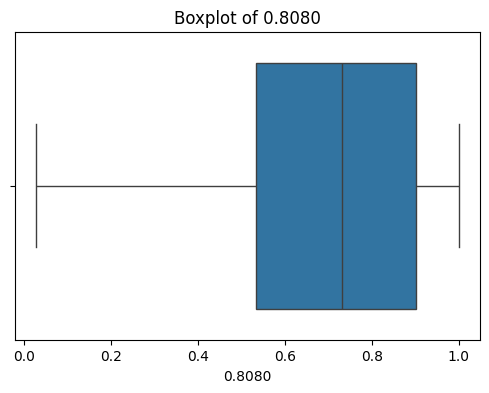

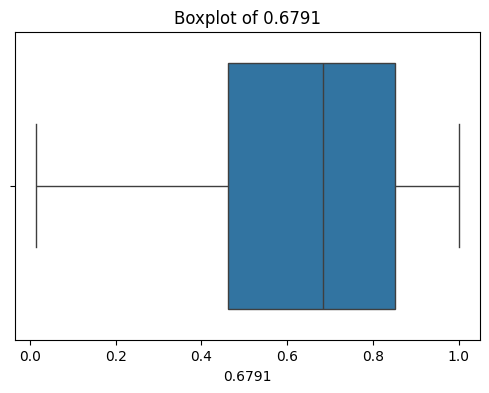

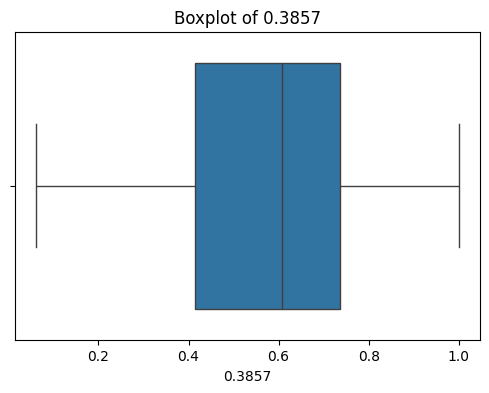

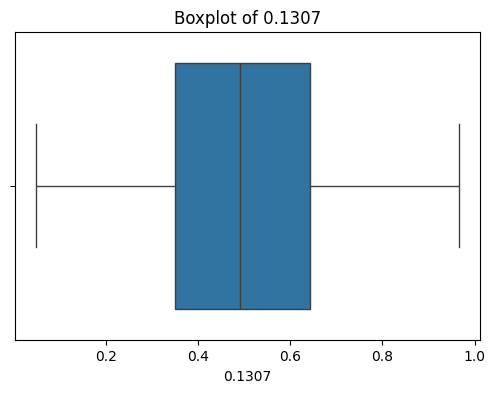

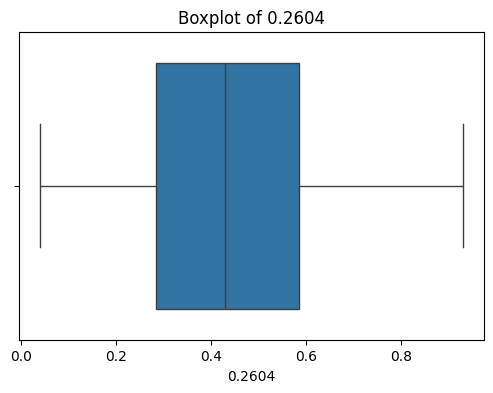

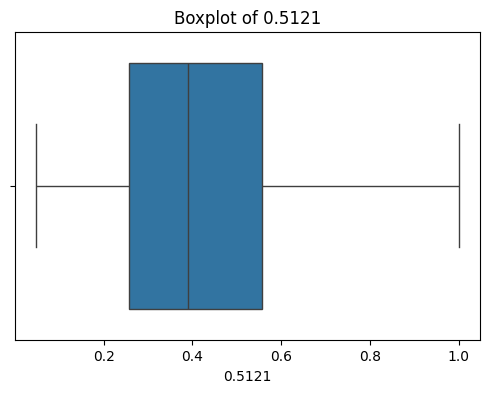

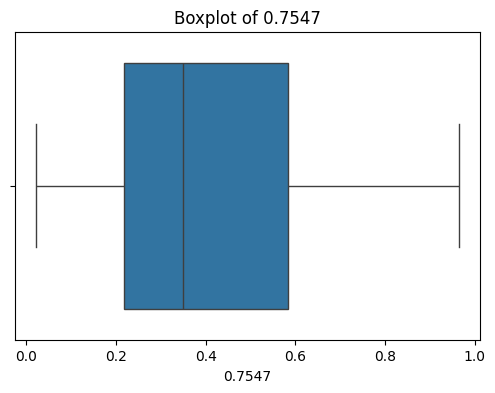

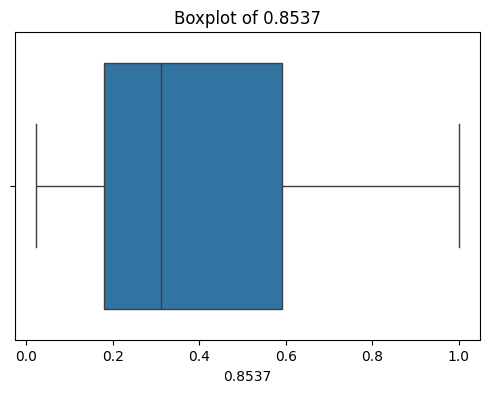

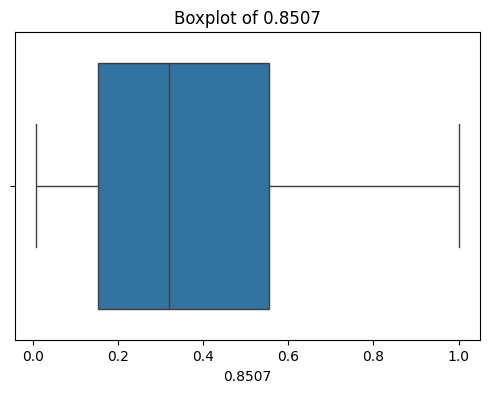

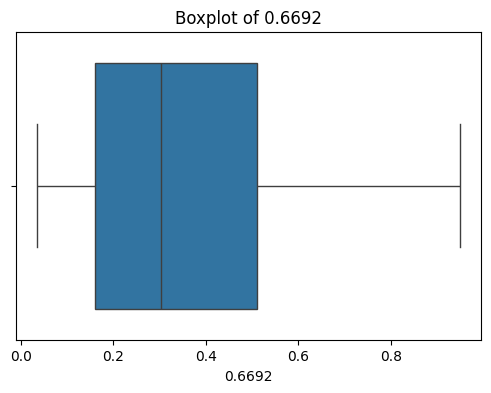

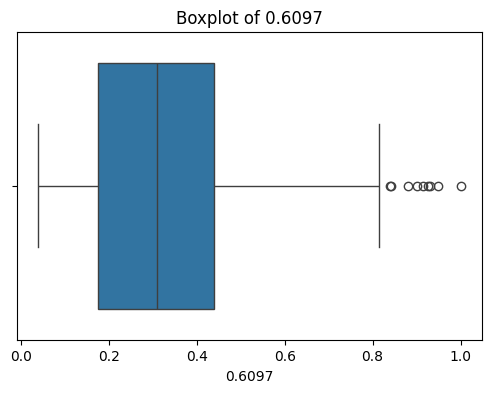

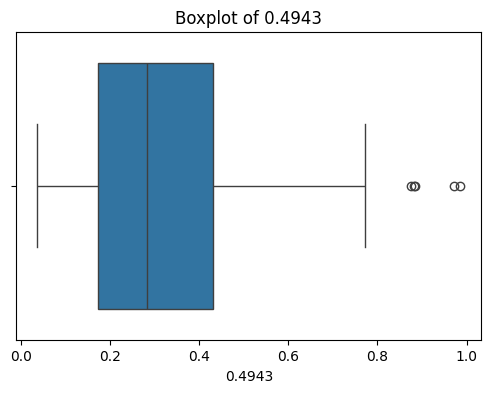

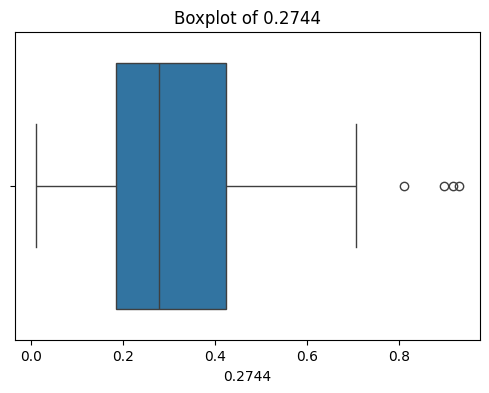

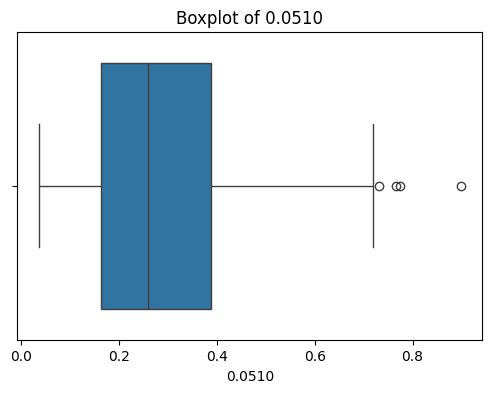

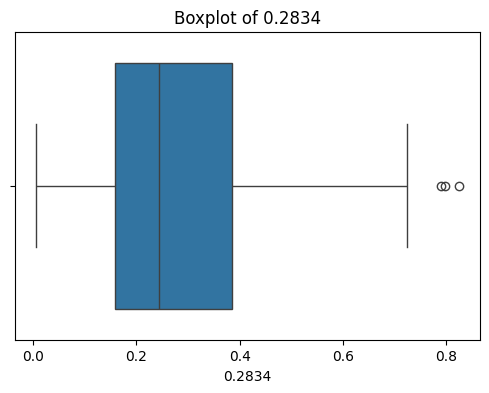

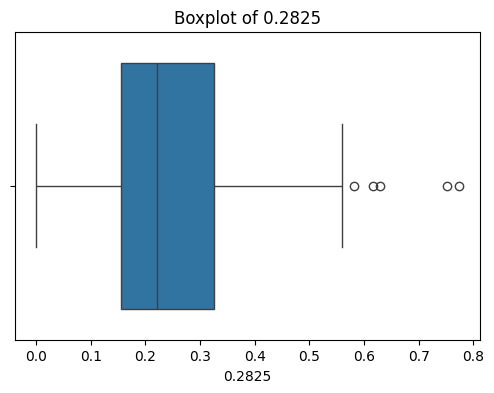

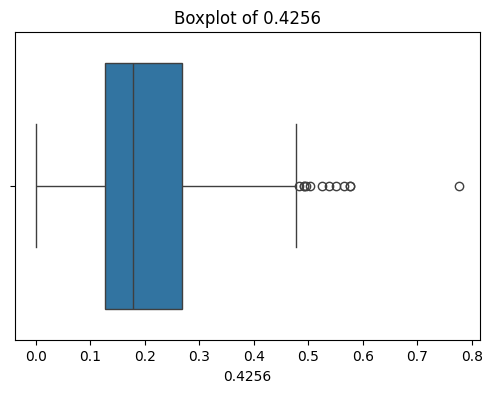

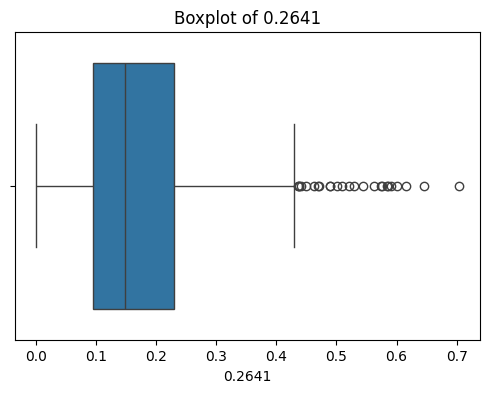

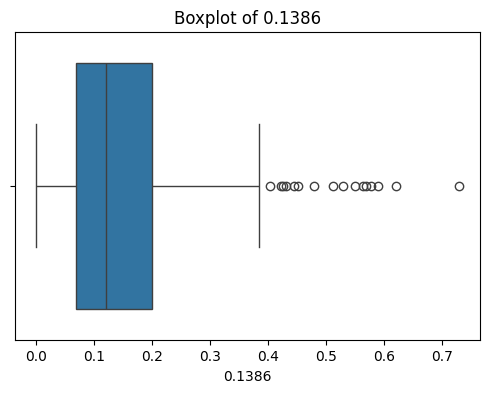

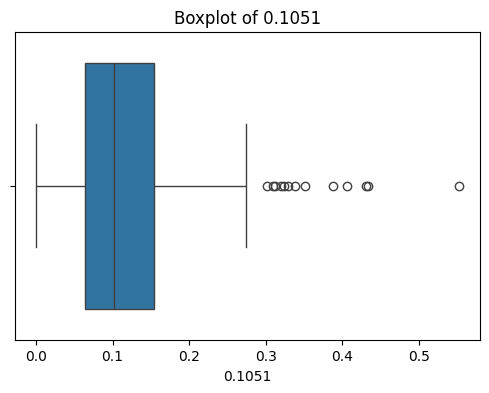

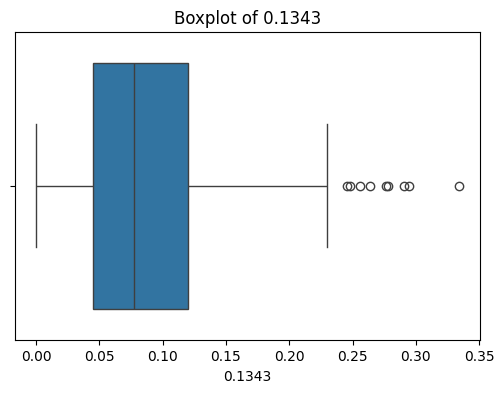

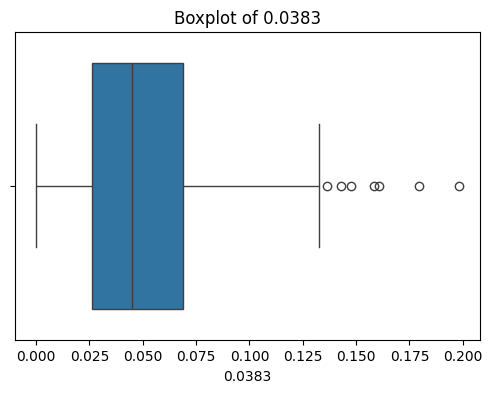

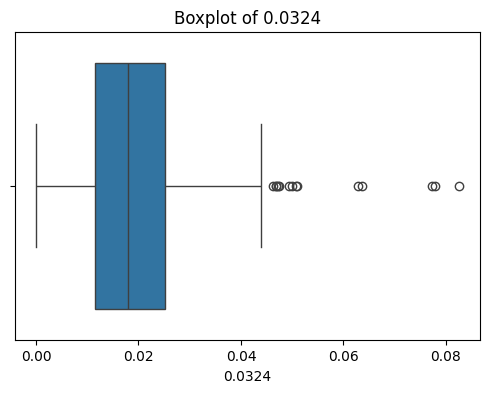

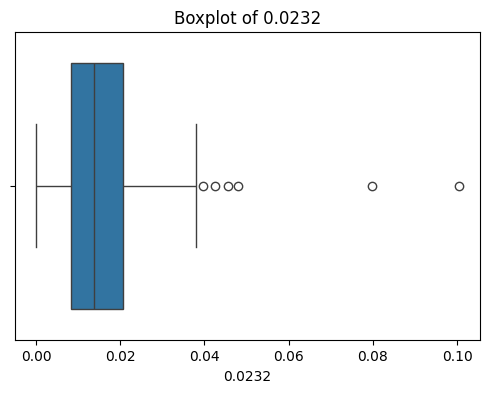

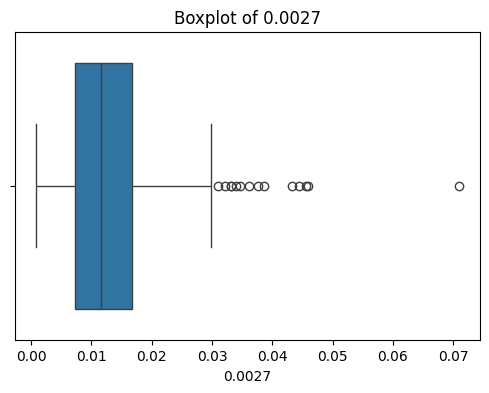

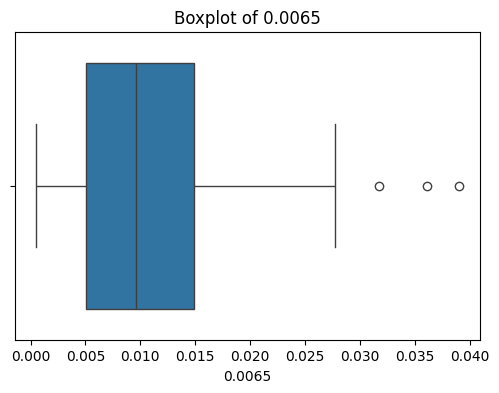

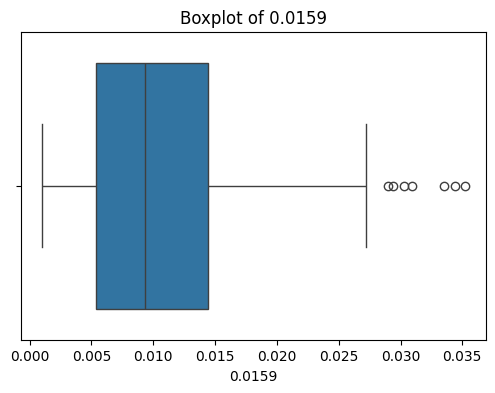

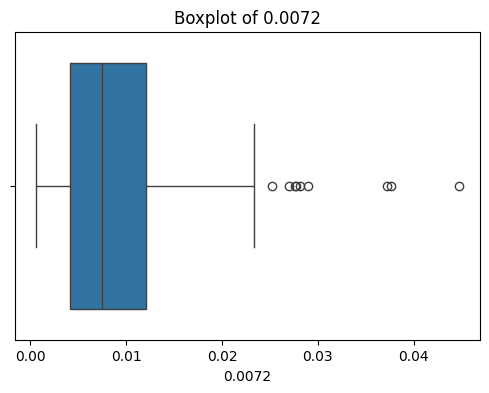

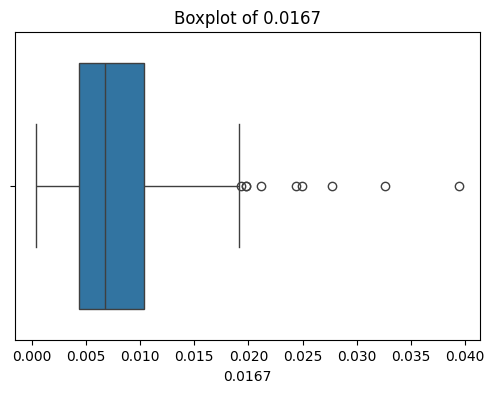

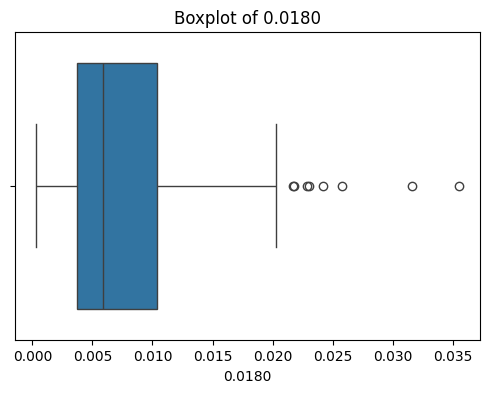

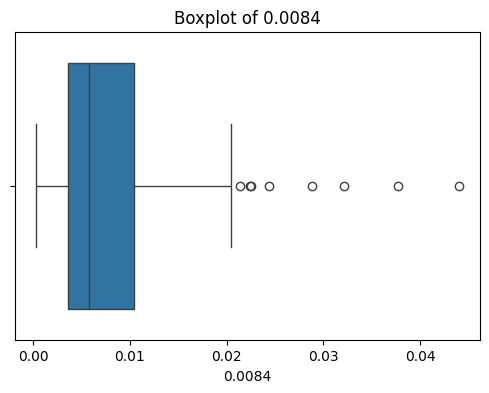

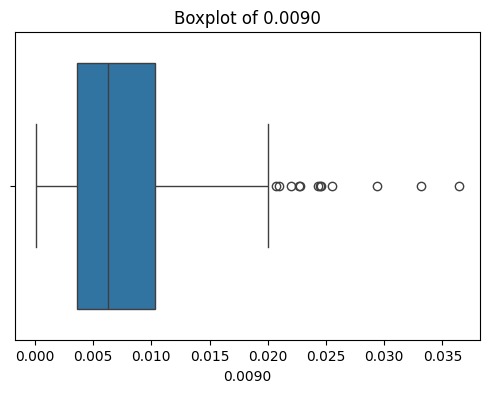

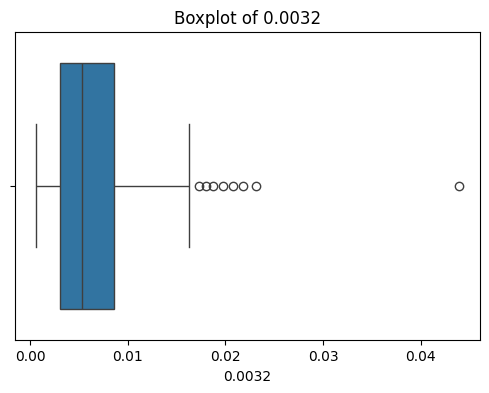

In [ ]:
# exclude the last column, which is the target
columns = df.columns[:-1]

for col in columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title("Boxplot of " + col)
    plt.show()

In [ ]:
df_new = df.copy()

columns = df_new.columns[:-1] # exclude the last column (target)

for col in columns:
    Q1 = df_new[col].quantile(0.25)
    Q3 = df_new[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_new = df_new[
        (df_new[col] >= lower_limit) &
        (df_new[col] <= upper_limit)
    ]

# Update the main DataFrame 'df' with the cleaned data
df = df_new

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (80, 61)


In [ ]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [ ]:
#split the data into train and test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=15
)

In [ ]:
#Standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
#select Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8125
              precision    recall  f1-score   support

           M       0.78      0.88      0.82         8
           R       0.86      0.75      0.80         8

    accuracy                           0.81        16
   macro avg       0.82      0.81      0.81        16
weighted avg       0.82      0.81      0.81        16

[[7 1]
 [2 6]]


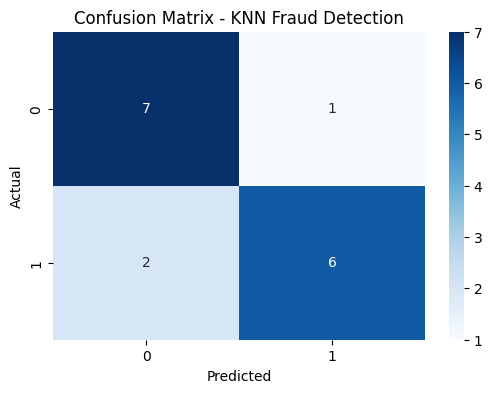

In [ ]:
from sklearn.metrics import confusion_matrix

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN Fraud Detection")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred = knn.predict(x_test)
y_proba = knn.predict_proba(x_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred))
roc_auc = roc_auc_score(
y_test,
y_proba,
multi_class='ovr'
)
print("ROC-AUC Score:", roc_auc)

Accuracy: 0.8125
ROC-AUC Score: 0.9140625


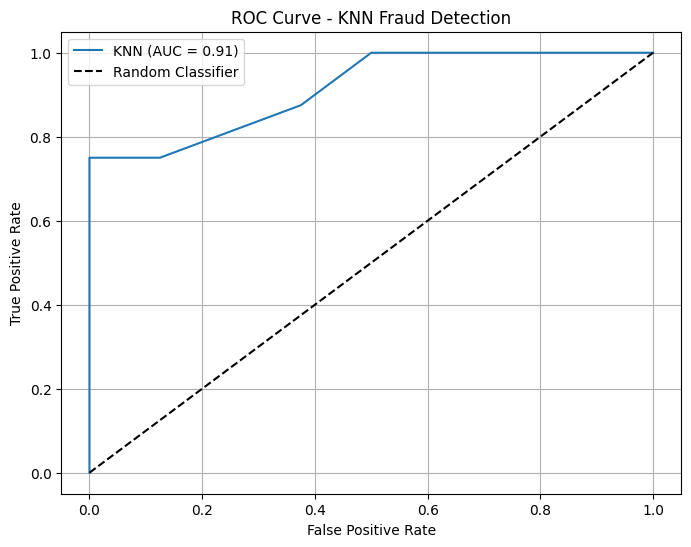

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Convert string labels 'R' and 'M' to numerical (1 and 0)
# Assuming 'R' is the positive class (1) and 'M' is the negative class (0)
y_test_binary = y_test.apply(lambda x: 1 if x == 'R' else 0)

# Recalculate roc_auc for binary classification using the binarized y_test
# The y_proba from knn.predict_proba(x_test)[:, 1] typically corresponds to the positive class probability.
roc_auc_binary = roc_auc_score(y_test_binary, y_proba)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_binary, y_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'KNN (AUC = {roc_auc_binary:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - KNN Fraud Detection")

plt.legend()
plt.grid()

plt.show()

In [ ]:
overall_auc = roc_auc_score(
y_test,
y_proba,
multi_class='ovr'
)
print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 0.9140625
